# OU process - Work sheet - Pridict $S_\theta$
## OU process basic information
Consider the OU process

$$
dx_t = -\beta x_t dt + \sigma dW_t, \quad x(0) \sim p_0(x_0).
$$

The solution is

$$
x_t = \mu_t(x_0) + \sigma_t \epsilon, \quad \epsilon \sim \mathcal{N}(0, 1),
$$

where

$$
\mu_t(x_0) = e^{-\beta t} x_0, \quad \sigma_t^2 = \frac{\sigma^2}{2\beta}(1 - e^{-2\beta t}).
$$

So, given a terminal time $T$, we can generate $x_t$, for $t \in [0, T]$.

# 1. Dataset and Training(Spiral)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 建議用 GPU
batch_size = 2048


def get_spiral_data(n_samples):
    theta = torch.sqrt(torch.rand(n_samples)) * 6 * np.pi 
    r = theta
    x = r * torch.cos(theta)
    y = r * torch.sin(theta)    
    data = torch.stack([x, y], dim=1)
    # 標準化到 [-1, 1] 附近
    return data / (6 * np.pi) 

# 初始化範圍建議：既然數據在 [-1, 1]，初始化可以灑在 [-1.2, 1.2]
# x_init = torch.rand(n_samples, 2) * 2.4 - 1.2
def marginal_prob_std(t, beta_min=0.1, beta_max=20.0):
    log_mean_coeff = -0.25 * t ** 2 * (beta_max - beta_min) - 0.5 * t * beta_min
    mean = torch.exp(log_mean_coeff)
    std = torch.sqrt(1. - torch.exp(2. * log_mean_coeff))
    return mean, std

def get_beta_schedule(t, beta_min=0.1, beta_max=20.0):
    """
    計算時間 t 當下的噪聲係數 beta(t)。
    這對應到 VP-SDE 中的線性噪聲排程。
    """
    return beta_min + t * (beta_max - beta_min)

In [9]:
class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class ScoreNet_SDE(nn.Module):
    def __init__(self, x_dim, hidden):
        super().__init__()
        self.embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=hidden),
            nn.Linear(hidden, hidden),
            nn.SiLU()
        )
        self.fc1 = nn.Linear(x_dim, hidden)
        self.layers = nn.ModuleList()
        for _ in range(4):
            self.layers.append(nn.Linear(hidden, hidden))
        self.fc_out = nn.Linear(hidden, x_dim)
        self.act = nn.SiLU()

    def forward(self, x, t):
        _, std = marginal_prob_std(t)
        std = std.view(-1, 1)

        t_embed = self.embed(t)
        h = self.fc1(x)
        h = h + t_embed
        h = self.act(h)
        for layer in self.layers:
            h = self.act(layer(h)) 
        
        h = self.fc_out(h)
        
        # Output: Score    <<<<<<<<<<<<<<<<<<<<<<<<<
        return h / std

def sde_score_matching_loss(model, x0):
    batch_size = x0.shape[0]
    # 這裡 t 不要從 0 開始，設大一點點 (1e-3) 避免除以 0 的邊緣效應
    t = torch.rand(batch_size, device=x0.device) * (1. - 1e-3) + 1e-3
    
    mean, std = marginal_prob_std(t)
    mean = mean.view(-1, 1)
    std = std.view(-1, 1)
    
    noise = torch.randn_like(x0) 
    xt = mean * x0 + std * noise
    
    # 1. 模型預測 Score (現在模型會吐出很大的值)
    score_pred = model(xt, t)
    
    # 2. 真實 Score (Ground Truth)
    # 筆記公式: -(Xt - mean*X0) / var = -noise / std
    score_target = -noise / std
    
    # 3. 計算 Loss
    # 原始 Score Matching Loss: || s - s_target ||^2
    # 【關鍵】必須加上 Likelihood Weighting (std^2)，否則梯度會爆炸
    losses = torch.sum((score_pred - score_target)**2, dim=1)
    loss = torch.mean(losses * (std ** 2))
    
    return loss

Start Spiral SDE Training...
Step  500 | Loss: 26.650198
Step 1000 | Loss: 19.593184
Step 1500 | Loss: 42.163971
Step 2000 | Loss: 37.778091
Step 2500 | Loss: 15.063547
Step 3000 | Loss: 32.405495
Step 3500 | Loss: 19.755304
Step 4000 | Loss: 45.963417
Step 4500 | Loss: 13.054255
Step 5000 | Loss: 31.237928


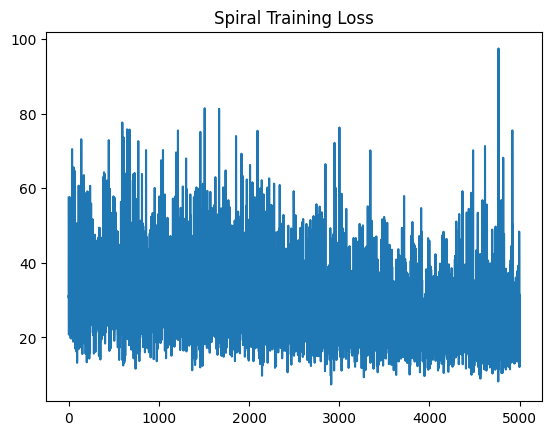

In [10]:
# =========== Training Loop (修正版) ===========
model = ScoreNet_SDE(x_dim=2, hidden=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Start Spiral SDE Training...")
n_step = 5000
loss_history = []

for step in range(1, n_step+1):
    x0 = get_spiral_data(batch_size).to(device)
    
    model.train()
    loss = sde_score_matching_loss(model, x0)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if step % 500 == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.6f}")

# 畫一下 Loss 曲線確認收斂
plt.plot(loss_history)
plt.title("Spiral Training Loss")
plt.show()

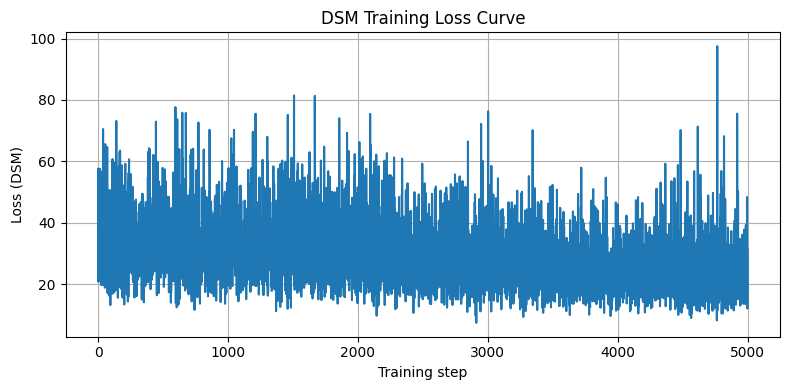

In [11]:
import matplotlib.pyplot as plt

def plot_loss_curve(loss_list):
    """
    loss_list: Python list or Tensor containing loss values for each step
    """
    plt.figure(figsize=(8,4))
    plt.plot(loss_list, linewidth=1.5)
    plt.xlabel("Training step")
    plt.ylabel("Loss (DSM)")
    plt.title("DSM Training Loss Curve")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_loss_curve(loss_history)

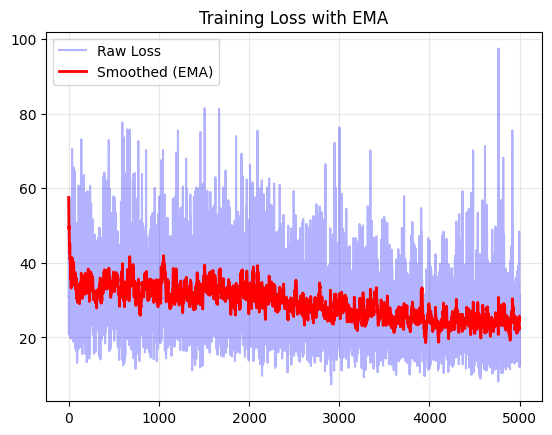

In [16]:
def plot_smooth_loss(loss_history, alpha=0.9):
    smooth_loss = []
    current_avg = loss_history[0]
    for val in loss_history:
        current_avg = alpha * current_avg + (1 - alpha) * val
        smooth_loss.append(current_avg)
    
    plt.plot(loss_history, alpha=0.3, color='blue', label='Raw Loss')
    plt.plot(smooth_loss, color='red', linewidth=2, label='Smoothed (EMA)')
    plt.title("Training Loss with EMA")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 呼叫畫圖
plot_smooth_loss(loss_history)

# 2. Sampling (Reverse)

Sampling Spiral with inspection...


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


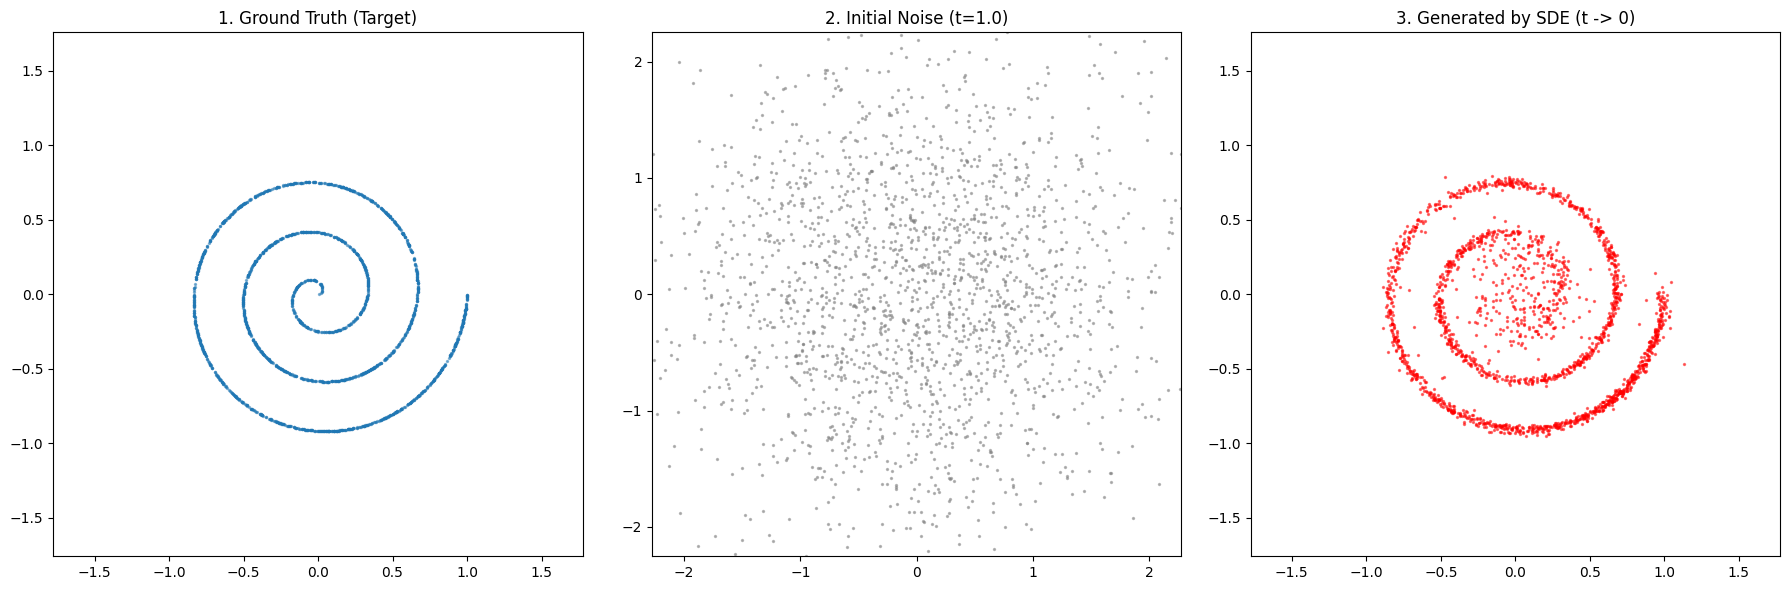

In [15]:
# =========== 3-Panel Sampling & Plotting for Spiral ===========

@torch.no_grad()
def p_sample_loop_spiral_inspect(model, shape, n_steps=2000):
    device = next(model.parameters()).device
    
    # 1. 這是起點：必須從標準常態分佈採樣 (Pure Gaussian Noise)
    x_init = torch.randn(shape, device=device)
    x = x_init.clone() # 複製一份，讓 x_init 保持原樣回傳以便畫圖
    
    # 時間軸從 1.0 倒數回 0.001
    time_steps = torch.linspace(1., 1e-3, n_steps + 1, device=device)
    
    for i in range(n_steps):
        t_current = time_steps[i]
        dt = t_current - time_steps[i+1]
        
        beta_t = get_beta_schedule(t_current)
        batch_t = torch.ones(shape[0], device=device) * t_current
        
        # 使用模型預測 Score (你的模型已經內含 /std，所以直接輸出就是 Score)
        score = model(x, batch_t)
        
        # Reverse SDE Update (Euler-Maruyama)
        drift = (-0.5 * beta_t * x - beta_t * score) * (-dt)
        diffusion = torch.sqrt(beta_t) * torch.sqrt(dt) * torch.randn_like(x)
        x = x + drift + diffusion
        
    # 回傳：(初始雜訊, 最終生成結果)
    return x_init.cpu().numpy(), x.cpu().numpy()

# --- 執行採樣並畫三張圖 ---
print("Sampling Spiral with inspection...")
model.eval()

# 取得 初始雜訊 與 生成結果 (螺旋建議步數設多一點，例如 2000)
x_start, x_end = p_sample_loop_spiral_inspect(model, shape=(2000, 2), n_steps=2000)

# 準備真實數據作對照
real_data = get_spiral_data(2000).cpu().numpy()

plt.figure(figsize=(18, 6)) # 加寬畫布

# 共用繪圖範圍設定
plot_limits = [-2, 2]

# 1. 真實數據 (Ground Truth)
plt.subplot(1, 3, 1)
plt.scatter(real_data[:,0], real_data[:,1], s=2, alpha=0.5, label='Real Data')
plt.title("1. Ground Truth (Target)")
plt.axis('equal')
plt.xlim(plot_limits); plt.ylim(plot_limits)

# 2. 初始狀態 (Initial Noise) - t=1.0 是一團圓形雜訊
plt.subplot(1, 3, 2)
plt.scatter(x_start[:,0], x_start[:,1], s=2, alpha=0.5, c='gray', label='Initial Noise')
plt.title("2. Initial Noise (t=1.0)")
plt.axis('equal')
plt.xlim(plot_limits); plt.ylim(plot_limits)

# 3. 生成結果 (Generated) - t->0 變成螺旋
plt.subplot(1, 3, 3)
plt.scatter(x_end[:,0], x_end[:,1], s=2, alpha=0.5, c='red', label='Generated')
plt.title("3. Generated by SDE (t -> 0)")
plt.axis('equal')
plt.xlim(plot_limits); plt.ylim(plot_limits)

plt.tight_layout()
plt.show()